<a href="https://colab.research.google.com/github/tohamym821-gif/Github-projects-analysis/blob/main/lv3_finalProject_Heba_DECI4_S_417793.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1 part(1)

#Step 1: Import the tools we need

In [626]:
import requests
import pandas as pd

#Step 2: Define the GitHub API URL to get top 100 machine learning repos

In [627]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

In [628]:
headers = {'User-Agent': 'Mozilla/5.0'}

#Step 4: Fetch the data from GitHub

In [629]:
response = requests.get(url, headers=headers)

#Step 5: Turn the web response into JSON data

In [630]:
data = response.json()

#Step 6: Get the list of repositories from the JSON data

In [631]:
if 'items' in data and len(data['items']) > 0:
    repos_list = data['items']

#Step 7: Convert the list into a Pandas DataFrame table

In [632]:
df = pd.DataFrame(repos_list)

#Step 8: Explore the Data

In [633]:
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,75769,2957,196657,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34088,2317,163244,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21752,7,88877,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15266,52,82194,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15584,20,73837,master,1.0


In [634]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

Task 1 part(2)

# 1. Select required columns

In [635]:
required_columns = [
    'name', 'owner', 'language', 'stargazers_count',
    'forks_count', 'watchers_count', 'open_issues_count',
    'created_at', 'updated_at', 'license'
]
df = df[required_columns]

# 2. Extract owner's username from nested dictionary

In [636]:
def get_owner_name(owner_data):
    if isinstance(owner_data, dict):
        return owner_data['login']
    return owner_data

In [637]:
df['owner'] = df['owner'].apply(get_owner_name)

# Step 3: Extract license name using a simple function

In [638]:
def get_license_name(license_data):
    if isinstance(license_data, dict):
        return license_data['name']
    return 'Unknown'

In [639]:
df['license'] = df['license'].apply(get_license_name)

In [640]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,196657,75769,196657,2957,2015-11-07T01:19:20Z,2026-08-02T08:46:27Z,Apache License 2.0
1,transformers,huggingface,Python,163244,34088,163244,2317,2018-10-29T13:56:00Z,2026-08-02T09:17:49Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88877,21752,88877,7,2021-03-03T01:34:05Z,2026-08-02T09:09:06Z,MIT License
3,funNLP,fighting41love,Python,82194,15266,82194,52,2018-08-21T11:20:39Z,2026-08-02T09:12:13Z,Unknown
4,awesome-machine-learning,josephmisiti,Python,73837,15584,73837,20,2014-07-15T19:11:19Z,2026-08-02T08:51:37Z,Other


# Step 4: Handle missing values (fill missing languages with 'Unknown')

In [641]:
df['language'] = df['language'].fillna('Unknown')

# Step 5: Remove duplicate records

In [642]:
df = df.drop_duplicates()

# Step 6: Convert date columns to proper datetime format

In [643]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

# Step 7: Rename columns for SQL analysis

In [644]:
df = df.rename(columns={
    'name': 'repo_name',
    'owner': 'owner_username',
    'language': 'primary_language',
    'stargazers_count': 'stars_count',
    'created_at': 'created_date',
    'updated_at': 'updated_date',
    'license': 'license_type'
})

In [645]:
df.head()

,repo_name,owner_username,primary_language,stars_count,forks_count,watchers_count,open_issues_count,created_date,updated_date,license_type
0,tensorflow,tensorflow,C++,196657,75769,196657,2957,2015-11-07 01:19:20+00:00,2026-08-02 08:46:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163244,34088,163244,2317,2018-10-29 13:56:00+00:00,2026-08-02 09:17:49+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88877,21752,88877,7,2021-03-03 01:34:05+00:00,2026-08-02 09:09:06+00:00,MIT License
3,funNLP,fighting41love,Python,82194,15266,82194,52,2018-08-21 11:20:39+00:00,2026-08-02 09:12:13+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,73837,15584,73837,20,2014-07-15 19:11:19+00:00,2026-08-02 08:51:37+00:00,Other


Task 1 part(3)

# 1. Save the cleaned dataset to a CSV file

In [646]:
df.to_csv('github_projects.csv', index=False)

# 2. Reload the CSV file to verify it

In [647]:
df_verify = pd.read_csv('github_projects.csv')

# 3. Display the first few rows

In [648]:
display(df_verify.head())

,repo_name,owner_username,primary_language,stars_count,forks_count,watchers_count,open_issues_count,created_date,updated_date,license_type
0,tensorflow,tensorflow,C++,196657,75769,196657,2957,2015-11-07 01:19:20+00:00,2026-08-02 08:46:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163244,34088,163244,2317,2018-10-29 13:56:00+00:00,2026-08-02 09:17:49+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88877,21752,88877,7,2021-03-03 01:34:05+00:00,2026-08-02 09:09:06+00:00,MIT License
3,funNLP,fighting41love,Python,82194,15266,82194,52,2018-08-21 11:20:39+00:00,2026-08-02 09:12:13+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,73837,15584,73837,20,2014-07-15 19:11:19+00:00,2026-08-02 08:51:37+00:00,Other


In [649]:
df_verify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   repo_name          100 non-null    object
 1   owner_username     100 non-null    object
 2   primary_language   100 non-null    object
 3   stars_count        100 non-null    int64 
 4   forks_count        100 non-null    int64 
 5   watchers_count     100 non-null    int64 
 6   open_issues_count  100 non-null    int64 
 7   created_date       100 non-null    object
 8   updated_date       100 non-null    object
 9   license_type       100 non-null    object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB


Task 2 part(1)

In [650]:
import sqlite3
import pandas as pd

# 1. Load the cleaned CSV file

In [651]:
df_sql = pd.read_csv('github_projects.csv')

# 2. Connect to (or create) the SQLite database file

In [652]:
conn = sqlite3.connect('github_data.db')

# 3. Import the dataset into a table named 'Repositories'

In [653]:
df_sql.to_sql('Repositories', conn, if_exists='replace', index=False)

100

# 4 & 5. Verify that the table was created and preview the data

In [654]:
query = "SELECT * FROM Repositories LIMIT 5"
preview_df = pd.read_sql_query(query, conn)

In [655]:
display(preview_df)

,repo_name,owner_username,primary_language,stars_count,forks_count,watchers_count,open_issues_count,created_date,updated_date,license_type
0,tensorflow,tensorflow,C++,196657,75769,196657,2957,2015-11-07 01:19:20+00:00,2026-08-02 08:46:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163244,34088,163244,2317,2018-10-29 13:56:00+00:00,2026-08-02 09:17:49+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88877,21752,88877,7,2021-03-03 01:34:05+00:00,2026-08-02 09:09:06+00:00,MIT License
3,funNLP,fighting41love,Python,82194,15266,82194,52,2018-08-21 11:20:39+00:00,2026-08-02 09:12:13+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,73837,15584,73837,20,2014-07-15 19:11:19+00:00,2026-08-02 08:51:37+00:00,Other


In [656]:
conn.close()

Task 2 part(2)

# Connect to the SQLite database

In [657]:
conn = sqlite3.connect('github_data.db')

# 1. Filter repositories with more than 10,000 stars

In [658]:
q1 = "SELECT * FROM Repositories WHERE stars_count > 10000"
display(pd.read_sql_query(q1, conn).head())

,repo_name,owner_username,primary_language,stars_count,forks_count,watchers_count,open_issues_count,created_date,updated_date,license_type
0,tensorflow,tensorflow,C++,196657,75769,196657,2957,2015-11-07 01:19:20+00:00,2026-08-02 08:46:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163244,34088,163244,2317,2018-10-29 13:56:00+00:00,2026-08-02 09:17:49+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88877,21752,88877,7,2021-03-03 01:34:05+00:00,2026-08-02 09:09:06+00:00,MIT License
3,funNLP,fighting41love,Python,82194,15266,82194,52,2018-08-21 11:20:39+00:00,2026-08-02 09:12:13+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,73837,15584,73837,20,2014-07-15 19:11:19+00:00,2026-08-02 08:51:37+00:00,Other


# 2. Find repositories whose name contains 'Machine'

In [659]:
q2 = "SELECT * FROM Repositories WHERE repo_name LIKE '%Machine%'"
display(pd.read_sql_query(q2, conn).head())

,repo_name,owner_username,primary_language,stars_count,forks_count,watchers_count,open_issues_count,created_date,updated_date,license_type
0,awesome-machine-learning,josephmisiti,Python,73837,15584,73837,20,2014-07-15 19:11:19+00:00,2026-08-02 08:51:37+00:00,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,35878,7397,35878,67,2021-01-02 12:08:37+00:00,2026-08-02 08:51:17+00:00,Unknown
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28845,6153,28845,32,2016-10-09 21:20:25+00:00,2026-08-02 03:09:07+00:00,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24723,4191,24723,31,2018-11-01 04:34:19+00:00,2026-08-02 08:17:53+00:00,MIT License
4,awesome-production-machine-learning,EthicalML,Unknown,20814,2589,20814,31,2018-08-15 14:28:41+00:00,2026-08-02 02:02:12+00:00,MIT License


# 3. Display Top 10 repositories based on stars

In [660]:
q3 = "SELECT * FROM Repositories ORDER BY stars_count DESC LIMIT 10"
display(pd.read_sql_query(q3, conn))

,repo_name,owner_username,primary_language,stars_count,forks_count,watchers_count,open_issues_count,created_date,updated_date,license_type
0,tensorflow,tensorflow,C++,196657,75769,196657,2957,2015-11-07 01:19:20+00:00,2026-08-02 08:46:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163244,34088,163244,2317,2018-10-29 13:56:00+00:00,2026-08-02 09:17:49+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88877,21752,88877,7,2021-03-03 01:34:05+00:00,2026-08-02 09:09:06+00:00,MIT License
3,funNLP,fighting41love,Python,82194,15266,82194,52,2018-08-21 11:20:39+00:00,2026-08-02 09:12:13+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,73837,15584,73837,20,2014-07-15 19:11:19+00:00,2026-08-02 08:51:37+00:00,Other
5,scikit-learn,scikit-learn,Python,66852,27252,66852,2112,2010-08-17 09:43:38+00:00,2026-08-02 06:45:02+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,gradio-app,Python,43267,3567,43267,206,2018-12-19 08:24:04+00:00,2026-08-02 09:17:32+00:00,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,35878,7397,35878,67,2021-01-02 12:08:37+00:00,2026-08-02 08:51:17+00:00,Unknown
8,C-Plus-Plus,TheAlgorithms,C++,34538,7843,34538,43,2016-07-16 10:19:45+00:00,2026-08-01 06:15:03+00:00,MIT License
9,netron,lutzroeder,JavaScript,33293,3175,33293,18,2010-12-26 12:53:43+00:00,2026-08-02 07:21:57+00:00,MIT License


# 4. Count total number of repositories

In [661]:
q4 = "SELECT COUNT(*) as total_repositories FROM Repositories"
display(pd.read_sql_query(q4, conn))

,total_repositories
0,100


# 5. Calculate average number of stars

In [662]:
q5 = "SELECT AVG(stars_count) as avg_stars FROM Repositories"
display(pd.read_sql_query(q5, conn))

,avg_stars
0,20732.17


# 6. Use logical operators (AND, OR, NOT)

In [663]:
q6 = """SELECT repo_name, primary_language, stars_count
FROM Repositories
WHERE (primary_language = 'Python' OR primary_language = 'C++')
  AND NOT stars_count < 50000"""
display(pd.read_sql_query(q6, conn))

,repo_name,primary_language,stars_count
0,tensorflow,C++,196657
1,transformers,Python,163244
2,funNLP,Python,82194
3,awesome-machine-learning,Python,73837
4,scikit-learn,Python,66852


In [664]:
df.head()

,repo_name,owner_username,primary_language,stars_count,forks_count,watchers_count,open_issues_count,created_date,updated_date,license_type
0,tensorflow,tensorflow,C++,196657,75769,196657,2957,2015-11-07 01:19:20+00:00,2026-08-02 08:46:27+00:00,Apache License 2.0
1,transformers,huggingface,Python,163244,34088,163244,2317,2018-10-29 13:56:00+00:00,2026-08-02 09:17:49+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,88877,21752,88877,7,2021-03-03 01:34:05+00:00,2026-08-02 09:09:06+00:00,MIT License
3,funNLP,fighting41love,Python,82194,15266,82194,52,2018-08-21 11:20:39+00:00,2026-08-02 09:12:13+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,73837,15584,73837,20,2014-07-15 19:11:19+00:00,2026-08-02 08:51:37+00:00,Other


Task 2 part(3)

#1. Bar Chart: Top 10 Repositories by Stars

In [665]:
import matplotlib.pyplot as plt

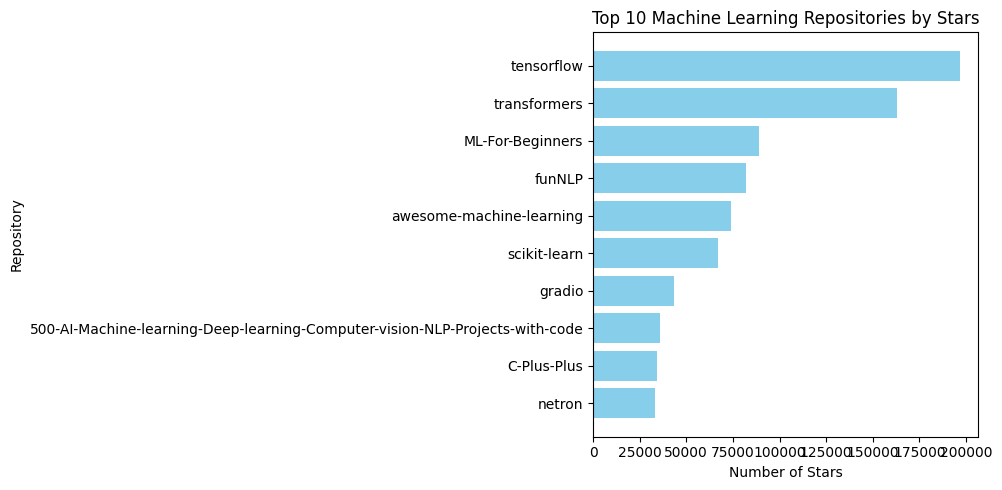

In [666]:
plt.figure(figsize=(10, 5))
top_10 = df.nlargest(10, 'stars_count')

plt.barh(top_10['repo_name'], top_10['stars_count'], color='skyblue')
plt.xlabel('Number of Stars')
plt.ylabel('Repository')
plt.title('Top 10 Machine Learning Repositories by Stars')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#2. Line Chart: Repository Creation Trend by Year

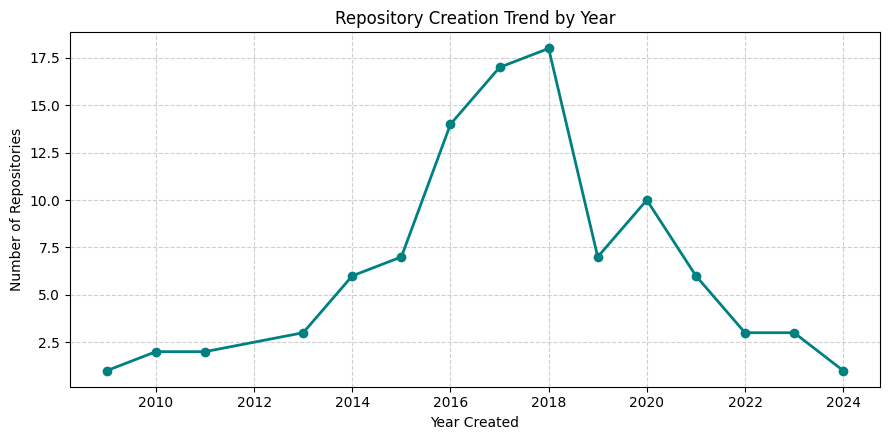

In [667]:
df['created_date'] = pd.to_datetime(df['created_date'])
df['created_year'] = df['created_date'].dt.year

yearly_counts = df['created_year'].value_counts().sort_index()

plt.figure(figsize=(9, 4.5))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o', color='teal', linewidth=2)
plt.xlabel('Year Created')
plt.ylabel('Number of Repositories')
plt.title('Repository Creation Trend by Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Task 3 part(1)and(2)

In [668]:
!git init

Reinitialized existing Git repository in /content/.git/


In [669]:
!git config --global user.email "tohamym821@gmail.com"
!git config --global user.name "Heba mostafa"

In [670]:
!git add .

In [671]:
!git commit -m "Initial project commit"

[main 087e1e7] Initial project commit
 2 files changed, 2 insertions(+), 2 deletions(-)


In [672]:
!git status

On branch main
nothing to commit, working tree clean
